In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

purchases = pd.read_csv(
    "/content/drive/MyDrive/Data/data/cleaned/online_retail_purchases.csv",
    parse_dates=["InvoiceDate"]
)

purchases["Revenue"] = (
    purchases["Quantity"]
    * purchases["UnitPrice"]
)

monthly_revenue = (
    purchases
    .set_index("InvoiceDate")["Revenue"]
    .resample("MS")
    .sum()
)

# Remove partial December 2011
monthly_revenue = monthly_revenue[
    monthly_revenue.index < "2011-12-01"
]

print("Number of complete months:", len(monthly_revenue))
monthly_revenue

Number of complete months: 24


,Revenue
InvoiceDate,
2009-12-01,683504.010
2010-01-01,555802.672
2010-02-01,504558.956
2010-03-01,696978.471
2010-04-01,591982.002
2010-05-01,597833.380
2010-06-01,636371.130
2010-07-01,589736.170
2010-08-01,602224.600


# Monthly Revenue Time-Series Analysis

Monthly sales revenue was calculated by aggregating all valid purchase transactions. December 2011 was excluded because the dataset contains transactions only up to 9 December, making it an incomplete month.

A damped Holt trend model was used to model the revenue series. This method estimates a current revenue level and a trend while gradually reducing the trend’s influence for longer forecast horizons. The final four complete months were reserved as a test period to evaluate forecasting performance.


In [2]:
train_revenue = monthly_revenue.iloc[:-4]
test_revenue = monthly_revenue.iloc[-4:]

print("Training period:")
print(
    train_revenue.index.min(),
    "to",
    train_revenue.index.max()
)

print("\nTesting period:")
print(
    test_revenue.index.min(),
    "to",
    test_revenue.index.max()
)

Training period:
2009-12-01 00:00:00 to 2011-07-01 00:00:00

Testing period:
2011-08-01 00:00:00 to 2011-11-01 00:00:00


In [3]:
from statsmodels.tsa.holtwinters import (
    ExponentialSmoothing
)

holt_model = ExponentialSmoothing(
    train_revenue,
    trend="add",
    damped_trend=True,
    seasonal=None,
    initialization_method="estimated"
).fit(
    optimized=True
)

test_forecast = holt_model.forecast(
    len(test_revenue)
)

In [4]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

mae = mean_absolute_error(
    test_revenue,
    test_forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test_revenue,
        test_forecast
    )
)

mape = np.mean(
    np.abs(
        (test_revenue - test_forecast)
        / test_revenue
    )
) * 100

time_series_metrics = pd.Series({
    "MAE": mae,
    "RMSE": rmse,
    "MAPE (%)": mape
})

time_series_metrics.round(2)

,0
MAE,335153.80
RMSE,384962.07
MAPE (%),32.20


In [5]:
final_holt_model = ExponentialSmoothing(
    monthly_revenue,
    trend="add",
    damped_trend=True,
    seasonal=None,
    initialization_method="estimated"
).fit(
    optimized=True
)

future_forecast = final_holt_model.forecast(
    3
)

future_forecast.round(2)

,0
2011-12-01,1160132.88
2012-01-01,1175639.34
2012-02-01,1191068.26


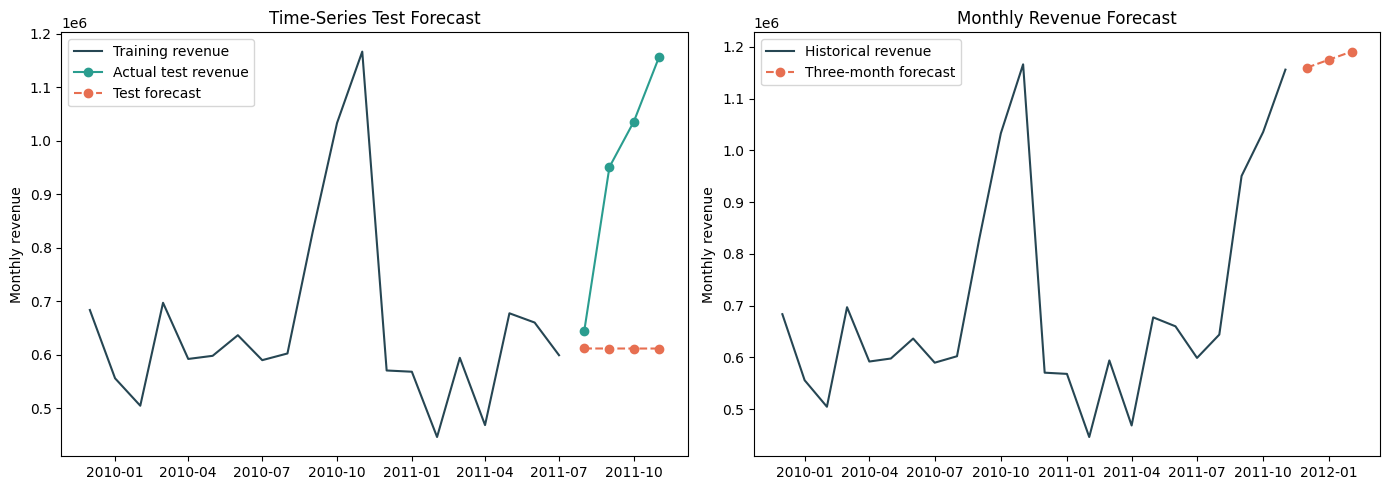

In [6]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Test-period evaluation
axes[0].plot(
    train_revenue.index,
    train_revenue,
    label="Training revenue",
    color="#264653"
)

axes[0].plot(
    test_revenue.index,
    test_revenue,
    label="Actual test revenue",
    color="#2A9D8F",
    marker="o"
)

axes[0].plot(
    test_forecast.index,
    test_forecast,
    label="Test forecast",
    color="#E76F51",
    linestyle="--",
    marker="o"
)

axes[0].set_title("Time-Series Test Forecast")
axes[0].set_ylabel("Monthly revenue")
axes[0].legend()

# Future forecast
axes[1].plot(
    monthly_revenue.index,
    monthly_revenue,
    label="Historical revenue",
    color="#264653"
)

axes[1].plot(
    future_forecast.index,
    future_forecast,
    label="Three-month forecast",
    color="#E76F51",
    linestyle="--",
    marker="o"
)

axes[1].set_title("Monthly Revenue Forecast")
axes[1].set_ylabel("Monthly revenue")
axes[1].legend()

plt.tight_layout()

plt.savefig(
    "monthly_revenue_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The non-seasonal Holt model produced a MAPE of 32.20% because it failed to capture the strong annual sales pattern. Therefore, a 12-month seasonal-naive model was used. This predicts each month using revenue from the corresponding month of the previous year. The method is appropriate for the short 24-month series and preserves the observed annual purchasing pattern.


In [7]:
seasonal_test_forecast = (
    monthly_revenue
    .shift(12)
    .loc[test_revenue.index]
)

seasonal_comparison = pd.DataFrame({
    "Actual": test_revenue,
    "Forecast": seasonal_test_forecast
})

seasonal_comparison.round(2)

,Actual,Forecast
InvoiceDate,,
2011-08-01,644051.04,602224.60
2011-09-01,950690.20,829013.95
2011-10-01,1035642.45,1033112.01
2011-11-01,1156205.61,1166460.02


In [8]:
seasonal_mae = mean_absolute_error(
    test_revenue,
    seasonal_test_forecast
)

seasonal_rmse = np.sqrt(
    mean_squared_error(
        test_revenue,
        seasonal_test_forecast
    )
)

seasonal_mape = np.mean(
    np.abs(
        (
            test_revenue -
            seasonal_test_forecast
        ) / test_revenue
    )
) * 100

seasonal_metrics = pd.Series({
    "MAE": seasonal_mae,
    "RMSE": seasonal_rmse,
    "MAPE (%)": seasonal_mape
})

seasonal_metrics.round(2)

,0
MAE,44071.89
RMSE,64548.66
MAPE (%),5.11


In [9]:
future_dates = pd.date_range(
    start=monthly_revenue.index[-1]
          + pd.offsets.MonthBegin(1),
    periods=3,
    freq="MS"
)

future_seasonal_forecast = pd.Series(
    [
        monthly_revenue.loc[
            date - pd.DateOffset(years=1)
        ]
        for date in future_dates
    ],
    index=future_dates,
    name="ForecastRevenue"
)

future_seasonal_forecast.round(2)

,ForecastRevenue
2011-12-01,570422.73
2012-01-01,568101.31
2012-02-01,446084.92


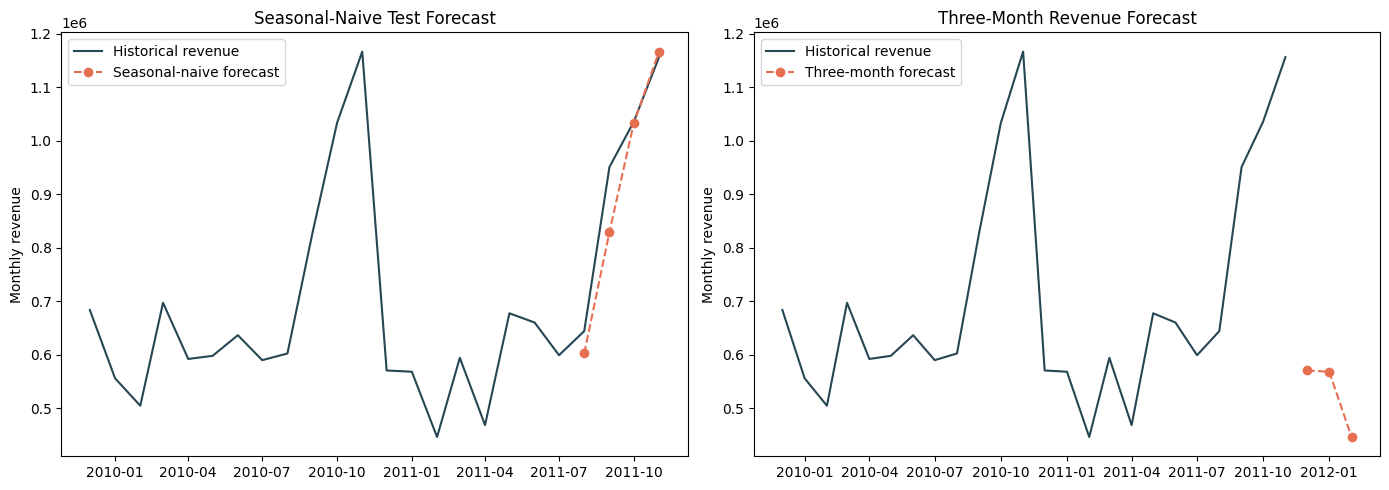

In [11]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].plot(
    monthly_revenue.index,
    monthly_revenue,
    color="#264653",
    label="Historical revenue"
)

axes[0].plot(
    test_revenue.index,
    seasonal_test_forecast,
    color="#E76F51",
    linestyle="--",
    marker="o",
    label="Seasonal-naive forecast"
)

axes[0].set_title(
    "Seasonal-Naive Test Forecast"
)
axes[0].set_ylabel("Monthly revenue")
axes[0].legend()

axes[1].plot(
    monthly_revenue.index,
    monthly_revenue,
    color="#264653",
    label="Historical revenue"
)

axes[1].plot(
    future_seasonal_forecast.index,
    future_seasonal_forecast,
    color="#E76F51",
    linestyle="--",
    marker="o",
    label="Three-month forecast"
)

axes[1].set_title(
    "Three-Month Revenue Forecast"
)
axes[1].set_ylabel("Monthly revenue")
axes[1].legend()

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Data/figures/seasonal_monthly_revenue_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Time-Series Results and Interpretation

The monthly revenue series displayed a repeating annual pattern, with revenue increasing strongly during September, October and November.

The seasonal-naive model achieved a mean absolute percentage error of 5.11%. Therefore, its monthly forecasts differed from the observed revenue by approximately 5.11% on average. This was substantially better than the non-seasonal Holt model, which produced a MAPE of 32.20%.

The seasonal-naive forecasts followed the observed test-period pattern closely, including the increase in revenue from August to November. This confirms that annual seasonality is an important characteristic of the retailer’s revenue.

The model forecast full-month revenue of 570,422.73 for December 2011, 568,101.31 for January 2012 and 446,084.92 for February 2012. These forecasts suggest that revenue is expected to decline after the October–November sales peak.

However, the dataset contains only 24 complete months. Consequently, the forecast assumes that the previous year’s seasonal pattern will repeat and should be interpreted as a short-term planning estimate rather than a long-term forecast.
